<a href="https://colab.research.google.com/github/xoxokhushii/restaurant-food-waste-prediction/blob/main/restaurant_food_waste_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
menu = pd.read_csv("menu_items.csv")
orders = pd.read_csv("order_details.csv")

In [3]:
menu.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


In [4]:
orders.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,1/1/23,11:38:36 AM,109.0
1,2,2,1/1/23,11:57:40 AM,108.0
2,3,2,1/1/23,11:57:40 AM,124.0
3,4,2,1/1/23,11:57:40 AM,117.0
4,5,2,1/1/23,11:57:40 AM,129.0


In [5]:
menu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   menu_item_id  32 non-null     int64  
 1   item_name     32 non-null     object 
 2   category      32 non-null     object 
 3   price         32 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  12234 non-null  int64  
 1   order_id          12234 non-null  int64  
 2   order_date        12234 non-null  object 
 3   order_time        12234 non-null  object 
 4   item_id           12097 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 478.0+ KB


Orders table → what was ordered
Menu table → details about that food

In [7]:
data = orders.merge(menu, left_on="item_id", right_on="menu_item_id")

In [8]:
data.head()

,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,1/1/23,11:38:36 AM,109.0,109,Korean Beef Bowl,Asian,17.95
1,2,2,1/1/23,11:57:40 AM,108.0,108,Tofu Pad Thai,Asian,14.50
2,3,2,1/1/23,11:57:40 AM,124.0,124,Spaghetti,Italian,14.50
3,4,2,1/1/23,11:57:40 AM,117.0,117,Chicken Burrito,Mexican,12.95
4,5,2,1/1/23,11:57:40 AM,129.0,129,Mushroom Ravioli,Italian,15.50


one food order + its category + price

In [9]:
data.shape

(12097, 9)

(number_of_orders , number_of_columns)

In [10]:
data = data[['order_id','order_date','item_name','category','price']]

In [12]:
data['order_date'] = pd.to_datetime(data['order_date'], format='%Y-%m-%d')

In [13]:
data['day_of_week'] = data['order_date'].dt.dayofweek
data['month'] = data['order_date'].dt.month

In [14]:
item_demand = data['item_name'].value_counts()

item_demand.head(10)

,count
item_name,
Hamburger,622
Edamame,620
Korean Beef Bowl,588
Cheeseburger,583
French Fries,571
Tofu Pad Thai,562
Steak Torta,489
Spaghetti & Meatballs,470
Mac & Cheese,463


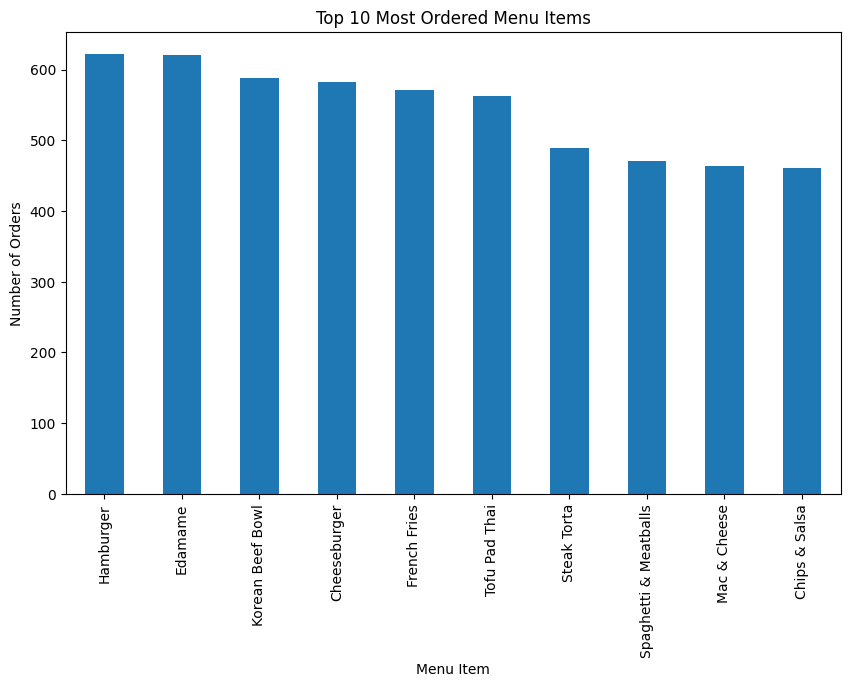

In [15]:
top_items = item_demand.head(10)

plt.figure(figsize=(10,6))
top_items.plot(kind='bar')

plt.title("Top 10 Most Ordered Menu Items")
plt.xlabel("Menu Item")
plt.ylabel("Number of Orders")

plt.show()

In [16]:
category_demand = data['category'].value_counts()

category_demand

,count
category,
Asian,3470
Italian,2948
Mexican,2945
American,2734


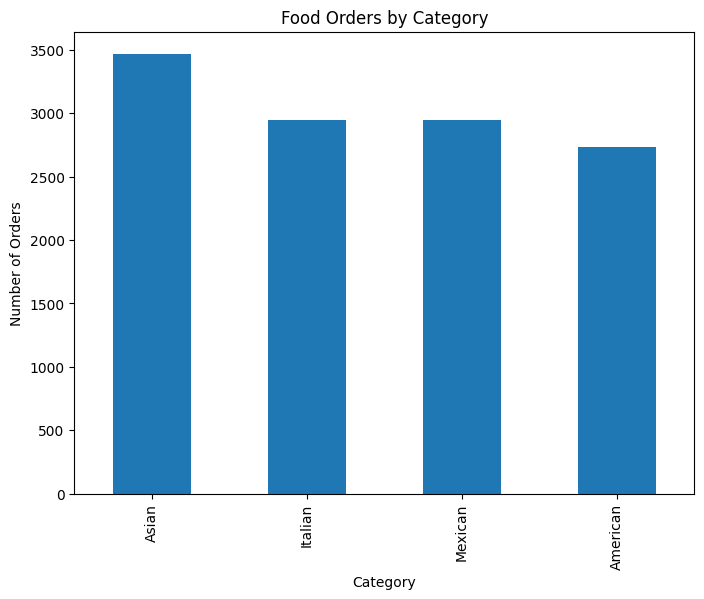

In [17]:
plt.figure(figsize=(8,6))
category_demand.plot(kind='bar')

plt.title("Food Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.show()

In [18]:
daily_orders = data.groupby('order_date').size()

daily_orders.head()

,0
order_date,
2023-01-01,160
2023-01-02,159
2023-01-03,150
2023-01-04,106
2023-01-05,121


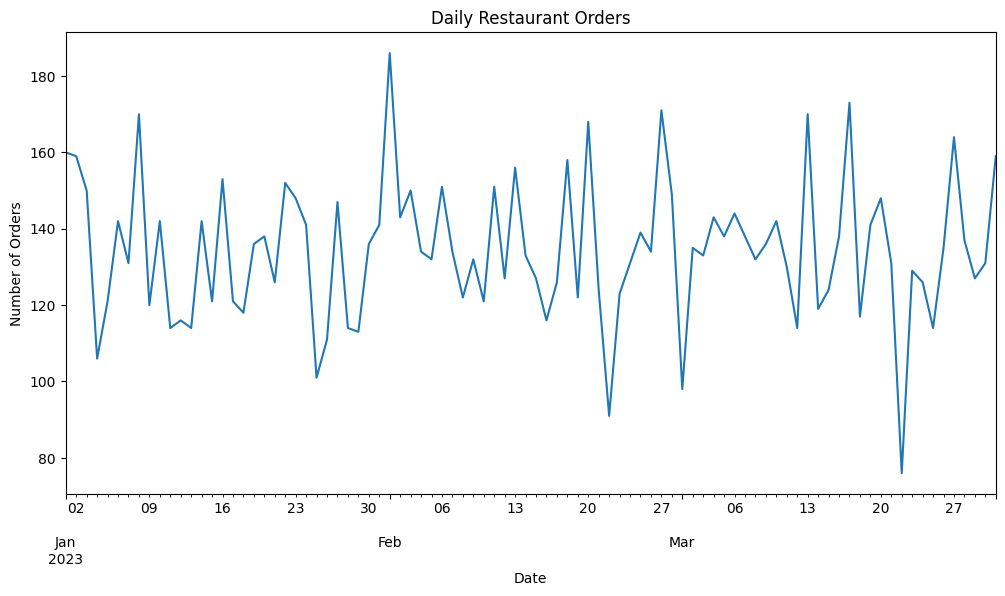

In [19]:
plt.figure(figsize=(12,6))

daily_orders.plot()

plt.title("Daily Restaurant Orders")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.show()

In [20]:
weekday_orders = data['day_of_week'].value_counts().sort_index()

weekday_orders

,count
day_of_week,
0,1988
1,1760
2,1522
3,1667
4,1802
5,1599
6,1759


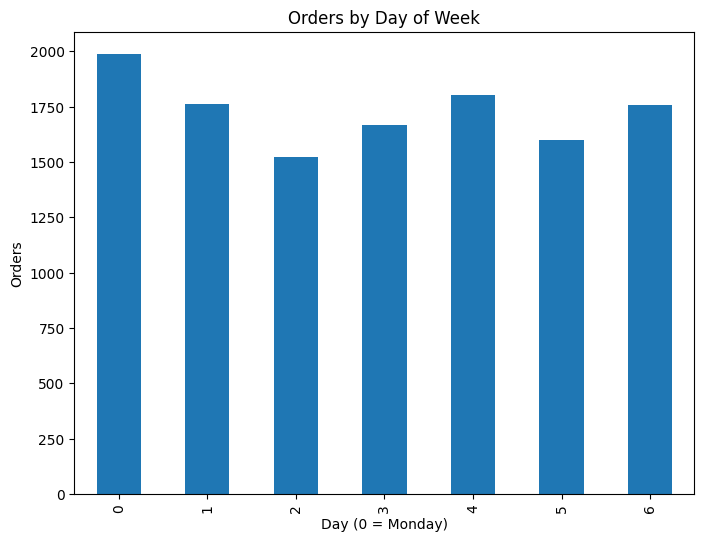

In [21]:
plt.figure(figsize=(8,6))

weekday_orders.plot(kind='bar')

plt.title("Orders by Day of Week")
plt.xlabel("Day (0 = Monday)")
plt.ylabel("Orders")

plt.show()

dish demand → ingredient usage → inventory planning

In [22]:
ingredient_map = {
    "Hamburger": ["bun","beef","lettuce","tomato"],
    "Cheeseburger": ["bun","beef","cheese","lettuce"],
    "Hot Dog": ["bun","sausage"],
    "Pizza": ["flour","cheese","tomato_sauce"],
    "Chicken Sandwich": ["bun","chicken","lettuce"],
    "Steak": ["beef","salt"],
    "Fries": ["potato","oil","salt"],
    "Salad": ["lettuce","tomato","cucumber"],
    "Chicken Wings": ["chicken","oil","spices"],
    "Tacos": ["tortilla","beef","lettuce"]
}

dish → ingredients used

In [23]:
ingredient_usage = {}

for item, count in item_demand.items():

    if item in ingredient_map:

        ingredients = ingredient_map[item]

        for ing in ingredients:

            if ing not in ingredient_usage:
                ingredient_usage[ing] = 0

            ingredient_usage[ing] += count

In [24]:
ingredient_df = pd.DataFrame(
    ingredient_usage.items(),
    columns=["ingredient","estimated_usage"]
)

ingredient_df = ingredient_df.sort_values(
    by="estimated_usage",
    ascending=False
)

ingredient_df.head()

,ingredient,estimated_usage
0,bun,1462
1,beef,1205
2,lettuce,1205
3,tomato,622
4,cheese,583


<Figure size 1000x600 with 0 Axes>

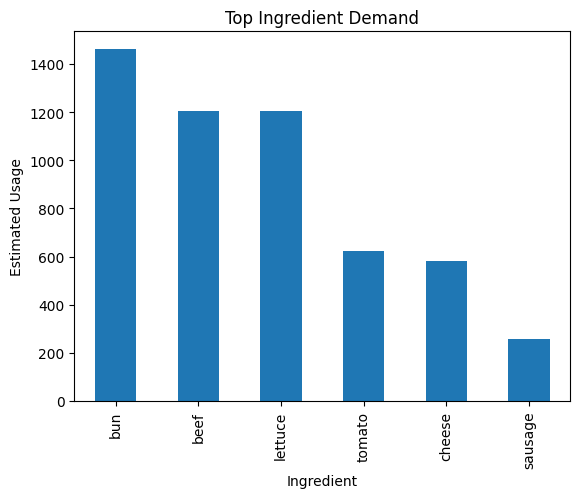

In [25]:
plt.figure(figsize=(10,6))

ingredient_df.head(10).plot(
    x="ingredient",
    y="estimated_usage",
    kind="bar",
    legend=False
)

plt.title("Top Ingredient Demand")
plt.xlabel("Ingredient")
plt.ylabel("Estimated Usage")

plt.show()

which ingredients restaurants must prepare most

In [26]:
daily_demand = data.groupby('order_date').size().reset_index(name='total_orders')

daily_demand.head()

,order_date,total_orders
0,2023-01-01,160
1,2023-01-02,159
2,2023-01-03,150
3,2023-01-04,106
4,2023-01-05,121


number of food items ordered each day

In [27]:
daily_demand['order_date'] = pd.to_datetime(daily_demand['order_date'])

daily_demand['day_of_week'] = daily_demand['order_date'].dt.dayofweek
daily_demand['month'] = daily_demand['order_date'].dt.month
daily_demand['day'] = daily_demand['order_date'].dt.day

In [28]:
daily_demand.head()

,order_date,total_orders,day_of_week,month,day
0,2023-01-01,160,6,1,1
1,2023-01-02,159,0,1,2
2,2023-01-03,150,1,1,3
3,2023-01-04,106,2,1,4
4,2023-01-05,121,3,1,5


In [29]:
X = daily_demand[['day_of_week','month','day']]
y = daily_demand['total_orders']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [32]:
predictions = model.predict(X_test)

In [33]:
predictions[:10]

array([135.36321945, 135.64271304, 129.26672137, 132.92481079,
       134.78403697, 129.11687693, 136.99467848, 141.08210593,
       136.84483403, 138.02507701])

In [36]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 13.435306346615263
R2 Score: -0.09431210140105017


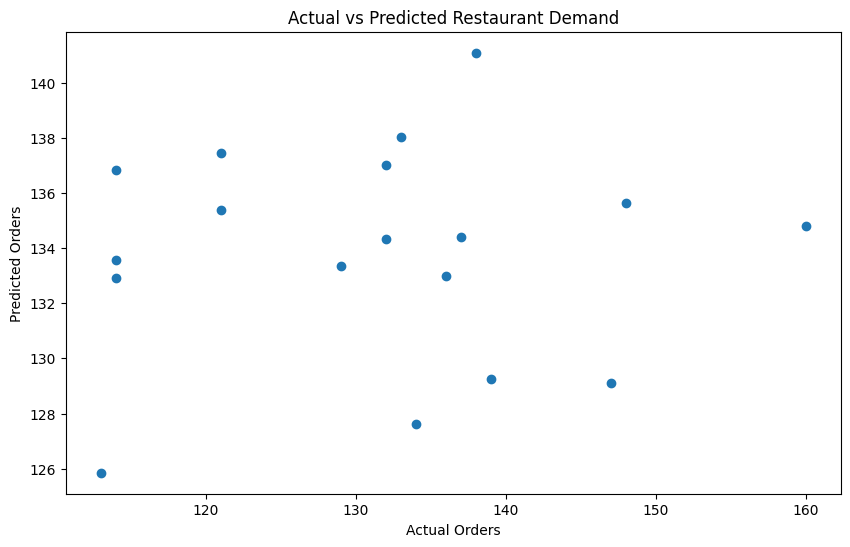

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")

plt.title("Actual vs Predicted Restaurant Demand")

plt.show()

In [38]:
plt.savefig("actual_vs_predicted_demand.png")

<Figure size 640x480 with 0 Axes>

In [39]:
future_example = pd.DataFrame({
    'day_of_week':[2],   # Wednesday
    'month':[6],
    'day':[15]
})

future_prediction = model.predict(future_example)

print("Predicted Orders:", int(future_prediction[0]))

Predicted Orders: 139


In [40]:
predicted_orders = int(future_prediction[0])

ingredient_need = ingredient_df.copy()

ingredient_need['estimated_usage'] = (
    ingredient_need['estimated_usage'] / ingredient_need['estimated_usage'].sum()
) * predicted_orders

ingredient_need.head()

,ingredient,estimated_usage
0,bun,38.098613
1,beef,31.401387
2,lettuce,31.401387
3,tomato,16.208849
4,cheese,15.192538


<Figure size 1000x600 with 0 Axes>

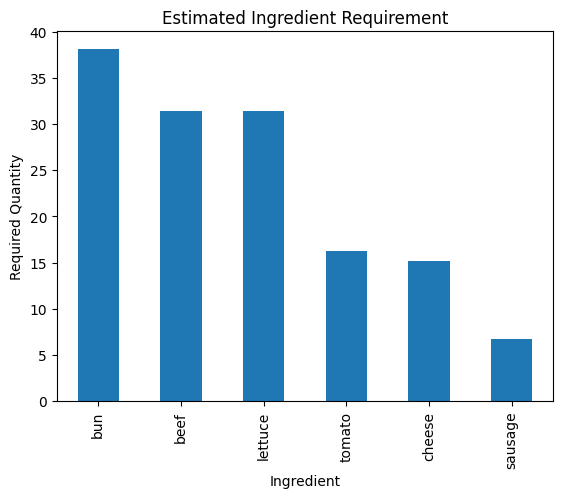

In [41]:
plt.figure(figsize=(10,6))

ingredient_need.head(10).plot(
    x="ingredient",
    y="estimated_usage",
    kind="bar",
    legend=False
)

plt.title("Estimated Ingredient Requirement")
plt.xlabel("Ingredient")
plt.ylabel("Required Quantity")

plt.show()

In [42]:
data.to_csv("processed_restaurant_orders.csv", index=False)